# Übung 1 #

## Aufgabe 1 - Farbbilder und Spiegelung ##

* 1. Lesen Sie ein Bild mit Hilfe von scikit-image ein und lassen Sie sich das Bild anzeigen.
* 2. Untersuchen Sie den Datentyp des eingelesenen Bildes. Wie ist ein Numpy Array aufgebaut?
* 3. Lassen Sie sich die drei Farbkanäle eines Bildes getrennt anzeigen.
* 4. Implementieren Sie eine Funktion, die ein eingelesenes Bild wahlweise horizontal oder vertikal spiegelt. (Verwenden Sie hierfür keine Numpy Funktionen).

In [2]:
#import cv2
import matplotlib.pyplot as plt
from skimage import io
import numpy as np

c:\Users\Ann-Kathrin\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\Ann-Kathrin\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\Ann-Kathrin\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


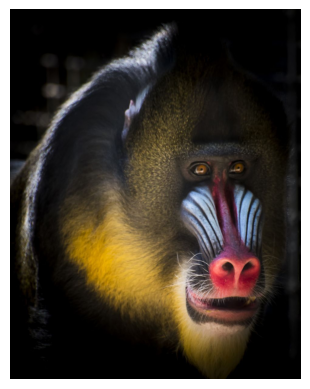

In [3]:
## 1
bild1 = io.imread("C:/Users/Ann-Kathrin/Desktop/htwg/semester05/2DCV/uebung1/monkey.jpg")
plt.imshow(bild1)
plt.axis("off")
plt.show()


In [51]:
## 2
print("Datentyp des Bildes: ", type(bild1)) # Bild wird als NumPy Array gespeichert
print("Form des Bildes (Höhe, Breite, Farbkanäle): ",bild1.shape) # Dimensionen sind Höhe, Breite, Farbkanäle
print("Datentyp der Werte: ", bild1.dtype) # jeder Pixel besteht aus 3 Werten (BRG)

Datentyp des Bildes:  <class 'numpy.ndarray'>
Form des Bildes (Höhe, Breite, Farbkanäle):  (1221, 960, 3)
Datentyp der Werte:  uint8


In [52]:
## 3
r = bild1[:, :, 0] #Kanal1
g = bild1[:, :, 1] #Kanal2
b = bild1[:, :, 2] #Kanal3

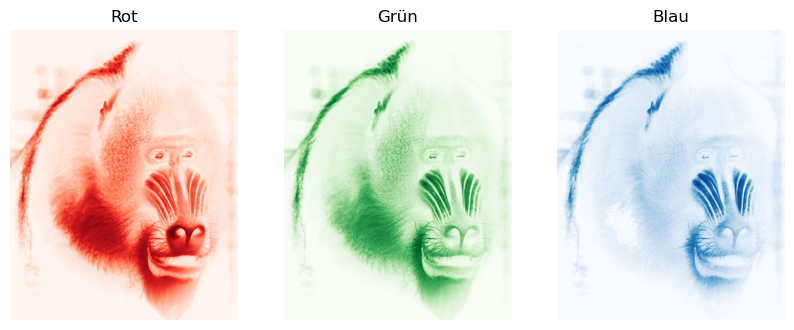

In [53]:
# plot
plt.figure(figsize=(10,8))

#rot
plt.subplot(1,3,1) #(höhe, breite, erster Kanal)
plt.imshow(r, cmap="Reds")
plt.title("Rot")
plt.axis("off")

#grün
plt.subplot(1,3,2)
plt.imshow(g, cmap="Greens")
plt.title("Grün")
plt.axis("off")

#blau
plt.subplot(1,3,3)
plt.imshow(b, cmap="Blues")
plt.title("Blau")
plt.axis("off")


plt.show()

In [27]:
## 4
## horizontal spiegeln → Zeilen bleiben (h), Spalten werden umgedreht (w)
## vertikal spiegeln → Spalten bleiben (w), Zeilen werden umgedreht (h)

#horizontal spiegeln funktion
def horizontal(bild1):
    h, w, k = bild1.shape
    bildNeu = np.zeros((h, w, k), dtype=bild1.dtype) # leeres Bild erzeugen

    for y in range(h):
        for x in range(w):
            bildNeu[y, w - 1 - x] = bild1[y, x] # bei vertikal wäre h-1-y, x
    return bildNeu
                

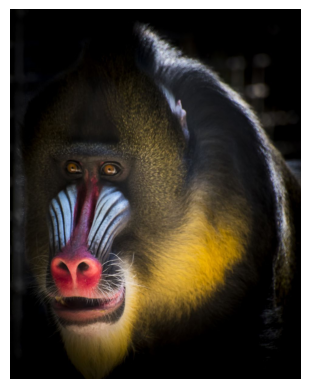

In [28]:
gespiegelt = horizontal(bild1)
plt.imshow(gespiegelt)
plt.axis("off")
plt.show()

## Aufgabe 2 - Histogramme, Binning und Lookup-Tabellen ##

* 1. Laden Sie das Buch ”Digitale Bildverarbeitung” aus Moodle herunter. Lesen Sie die
Kapitel 4- 5 (Histogramme und Punktoperationen).
* 2. Lesen Sie die Bilder mit Hilfe von scikit-image ein.
* 3. Schreiben Sie einen Funktion, die das Histogramm eines 8-Bit-Graustufenbildes (256 Intensitätsstufen) berechnet.
* 4. Berechnen Sie das Histogramm von den Bildern 01 bis 05. Sie werden zum einen Aufnahmefehler (Belichtungsfehler) in deren Histogrammen erkennen können. <br>
Zum anderen werden Sie die Bearbeitungsschritte in zwei bearbeiteten Bild anhand des Histogramms erkennen können. <br>
a) Welche Aufnahmefehler sind in 01 und 03 zu erkennen? Woran ist dies im Histogramm erkennbar? <br>
b) Bild01 ist das aufgenommene Bild. Bild02 wurde nachbearbeitet. Die Helligkeit wurde erhöht. 
Woran ist dies im Histogramm erkennbar? Welche Daten gehen dabei verloren? <br>
c) Bild04 ist das aufgenommene Bild. Bild05 wurde einem Bearbeitungsschritt unterzogen. Was wurde in Bild05 verändert? Woran kann man dies in seinem Histogramm erkennen? <br>
* 5. Implementieren Sie eine Funktion, die eine Punktoperation mithilfe einer Lookup-Tabelle zum Aufhellen eines Bildes durchführt. <br>
a) In Aufgabe (4b) gingen Daten beim Aufhellen eines Bildes verloren. Wie könnte dies vermieden werden? <br>
b) Damit beim Aufhellen von Bild01 keine Daten verloren gehen, soll eine Lookup Tabelle verwendet werden. <br>
Versuchen Sie mit der Lookup-Tabelle die dunklen Bildbereiche des Bildes aufzuhellen ohne die hellen Bereiche zu stark zu verändern

In [4]:
##2 alle Bilder einlesen
pfad = "C:/Users/Ann-Kathrin/Desktop/htwg/semester05/2DCV/uebung1/"
dateien = ["bild01.jpg", "bild02.jpg", "bild03.jpg", "bild04.jpg", "bild05.jpg"] #, "sea_wall.jpg", "wood.jpg", "hidden.png"

bilder = [io.imread(pfad + name) for name in dateien]

In [30]:
##3 in graustufen bild umwandeln
def bunt_zu_grau(image):
    gray = (
        0.299 * image[:, :, 0] +
        0.587 * image[:, :, 1] +
        0.114 * image[:, :, 2]
    )
    return gray.astype(np.uint8)

In [31]:
##3
def computeHisto(image):
    #falls bunt -> grau
    if len(image.shape) == 3:
        image = bunt_zu_grau(image)

    histo = np.zeros(256, dtype=int)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            histo[image[y, x]] += 1

    return histo

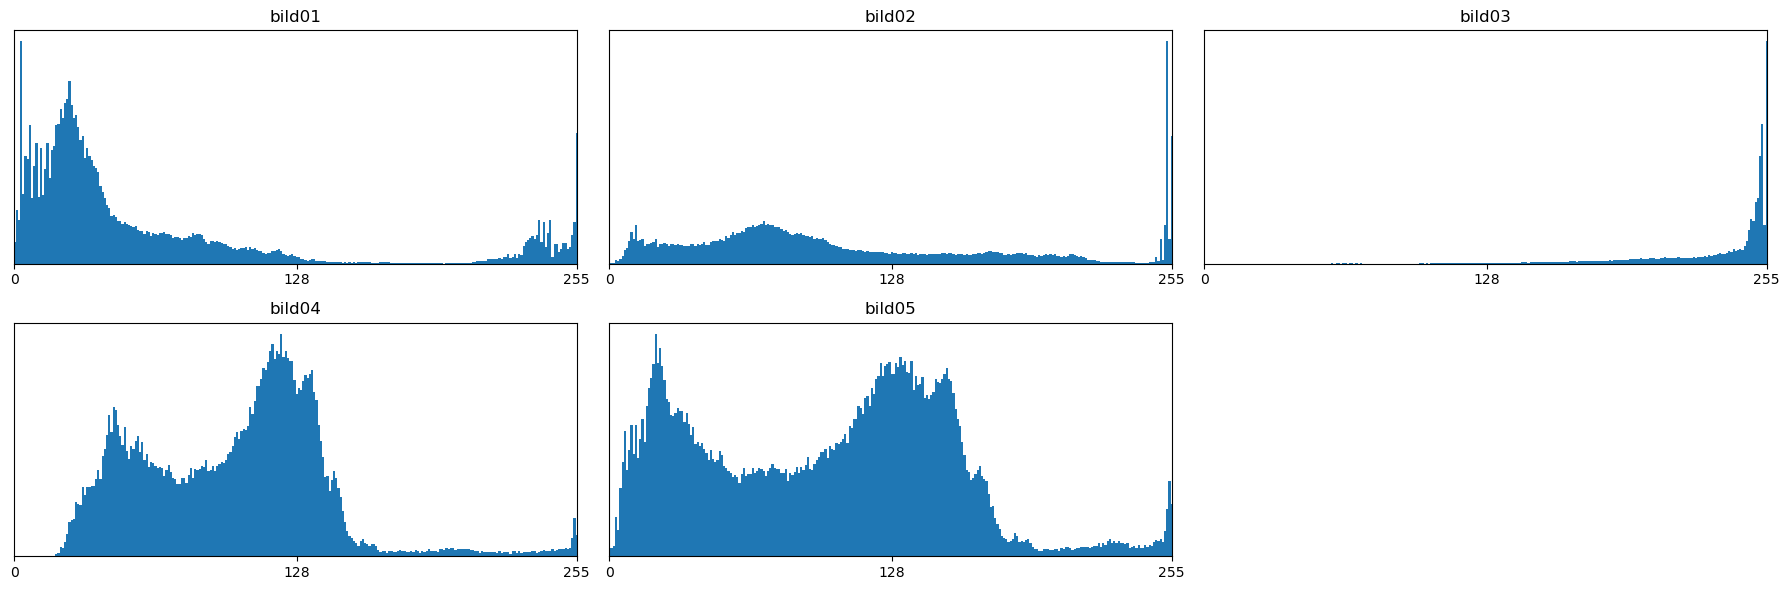

In [32]:
#3 histogramm 

plt.figure(figsize=(18, 6))

for i, name in enumerate(dateien, start=1):
    img = io.imread(pfad + name)
    histo = computeHisto(img)

    plt.subplot(2, 3, i)  # 2 Reihen, 3 Spalten
    plt.bar(range(256), histo, width=1)

    plt.title(name.split(".")[0])
    plt.xlim(0, 255)
    plt.xticks([0, 128, 255])
    
    plt.yticks([])

plt.tight_layout()
plt.show()

In [33]:
##4
#a) Aufnahmefehler in Bild 01 und Bild 03
#Bild 01: starke Häufung im linken Bereich ->Bild ist unterbelichtet
#Bild 03: starker Peak rechts ->Bild ist überbelichtet

#b)Bild 01 -> Bild 02: Verteilung ist nach rechts verschoben -> Bild wurde aufgehellt

#c) Bild 04 -> Bild 05: Verteilung ist breiter, dunkle Werte werden dunkler und helle heller (mehr extreme) -> Kontrast wurde verstärkt

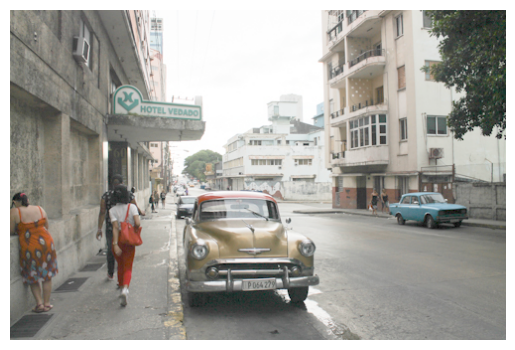

In [55]:
##5
#a) Datenverlust kann vermieden werden, indem die Erhöhung der Helligkeit
#nicht nur auf einen Punkt addiert werden sondern verteilt werden

#b)
def lookUp():
    lut = np.zeros(256, dtype=np.uint8) # Array mit 256 Einträgen

    gamma = 2  # 1/gammawert > 1 -> aufhellen, <1 abdunkeln

    for i in range(256):
        # formel: aMax*(a/aMax)**1/gamma
        lut[i] = np.clip(255 * (i / 255) ** (1/gamma), 0, 255)

    return lut

def lUaufBild(image, lut):
    result = np.zeros_like(image) #neues gleichgroß wie original

    for y in range(image.shape[0]): #Zeilen
        for x in range (image.shape[1]): #Spalten
            for z in range(image.shape[2]): #Farbkanäle
                result[y,x,z] = lut[image[y,x,z]] #pixel durch neuen wert aus tabelle ersetzen
    return result

lut = lookUp()
hellesBild = lUaufBild(bilder[1], lut)
plt.imshow(hellesBild)
plt.axis("off")
plt.show()